# Analisis Time Series Univariat

Analisis time series melibatkan berbagai metode untuk memahami pola, tren, dan melakukan peramalan berdasarkan data historis. Berikut adalah beberapa macam analisis time series yang sering digunakan:

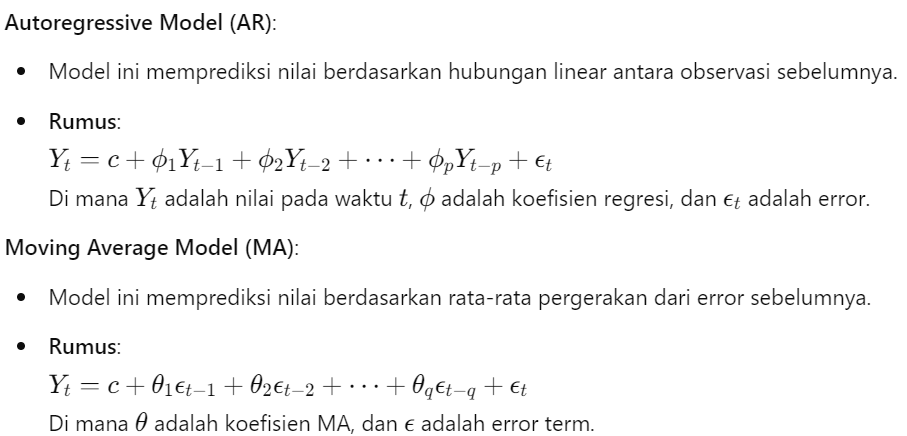

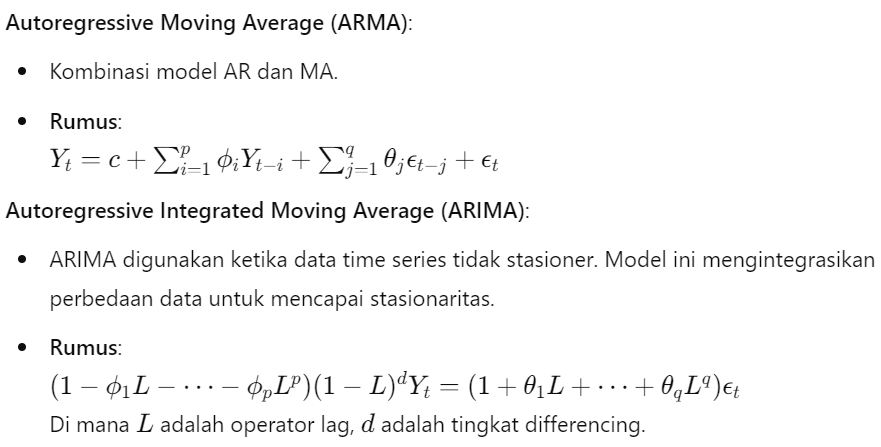

Berikut ini contoh penggunaan analisis ARIMA serta pengecekan asumsi stasionaritas dan autocorrelation.

1. Import Library

In [1]:
#pip install yfinance statsmodels matplotlib seaborn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

2. Ambil data saham ketika di tutup

[*********************100%%**********************]  1 of 1 completed

                Close
Date                 
2020-01-02  28.684000
2020-01-03  29.534000
2020-01-06  30.102667
2020-01-07  31.270666
2020-01-08  32.809334


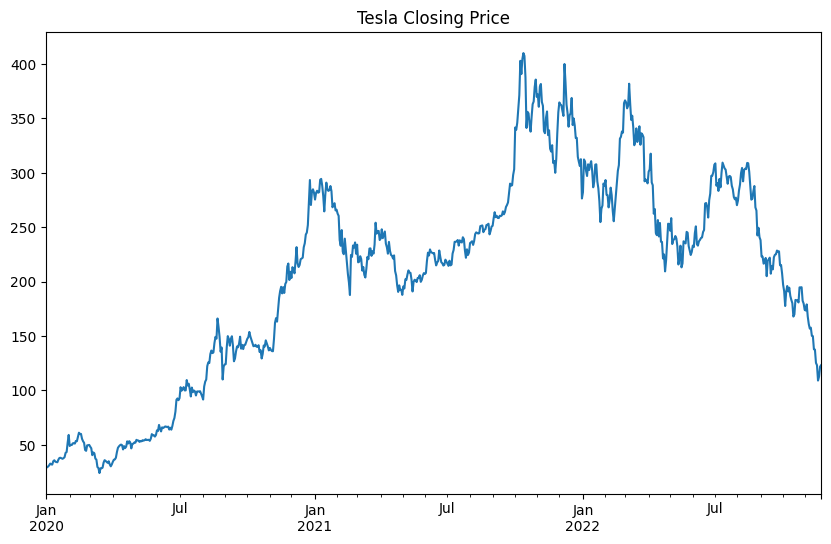

In [ ]:
# Ambil data saham Tesla (TSLA)
data = yf.download('BTC', start='2020-01-01', end='2023-01-01')
data = data[['Close']]  # Kita fokus pada harga penutupan
print(data.head())

# Set frekuensi pada indeks
data.index = pd.date_range(start='2020-01-01', periods=len(data), freq='B')  # B untuk hari kerja

# Visualisasi data harga penutupan
data['Close'].plot(figsize=(10,6), title='Tesla Closing Price')
plt.show()

In [3]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)


Jumlah missing values per kolom:
Close    0
dtype: int64


In [4]:
# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah nilai NaN per kolom:
Close    0
dtype: int64


3. Cek Asumsi Stasionaritas dengan Uji ADF (Augmented Dickey-Fuller Test)

In [5]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF
result = adfuller(data['Close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Cek Hipotesis
if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


ADF Statistic: -1.877528
p-value: 0.342705
Data tidak stasioner, lakukan differencing.


4. Jika Data Tidak Stasioner, Lakukan Differencing

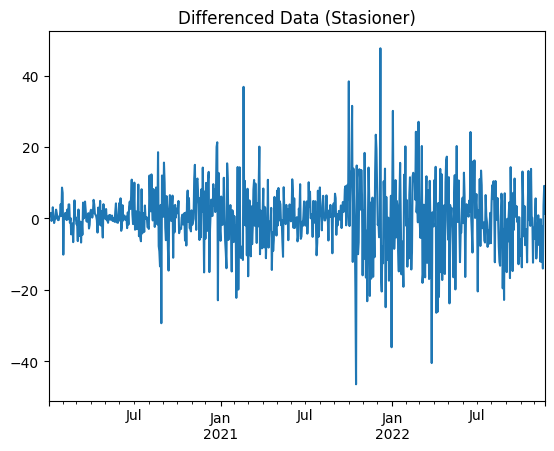

p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


In [6]:
# Lakukan Differencing jika data tidak stasioner
data_diff = data['Close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")
plt.show()

# Uji ADF lagi setelah differencing
result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])

# Cek Hipotesis
if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


In [7]:
# Cek apakah ada missing value
missing_values = data_diff.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data_diff.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah missing values per kolom:
0
Jumlah nilai NaN per kolom:
0


5. Cek Autocorrelation (ACF) dan Partial Autocorrelation (PACF)

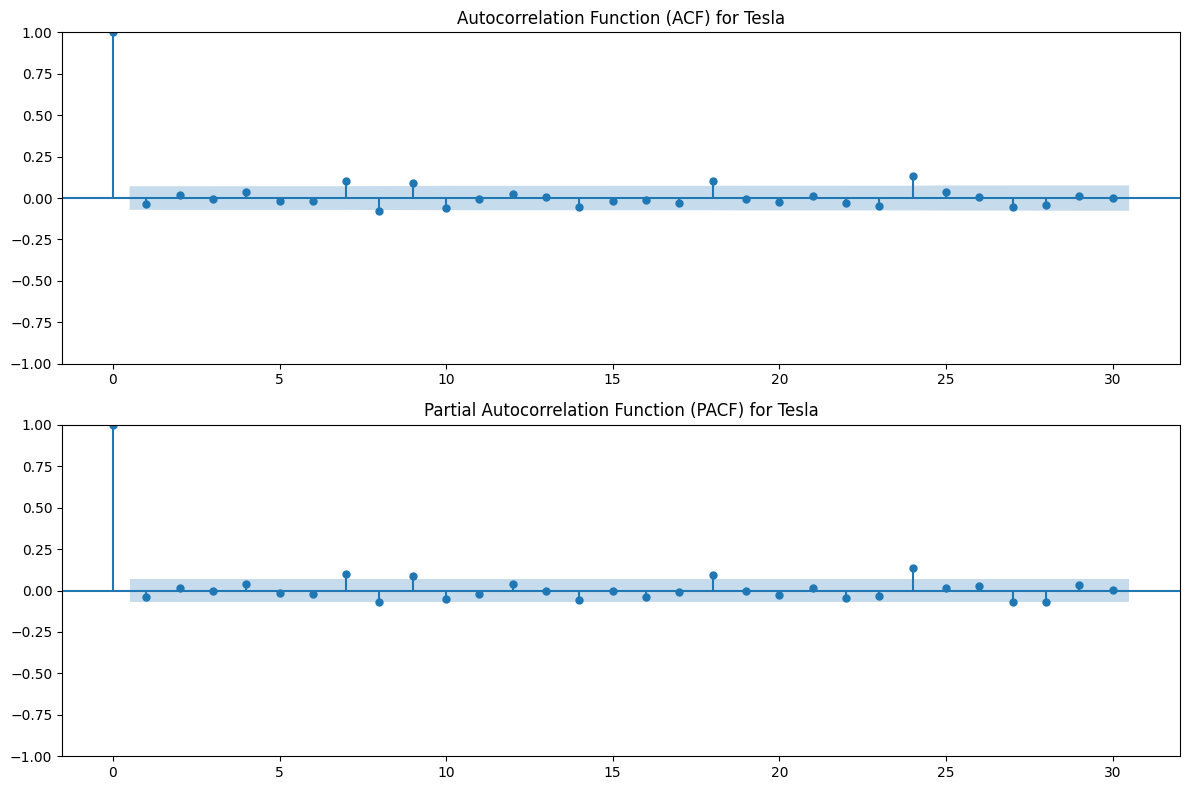

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for Tesla')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for Tesla')

plt.tight_layout()
plt.show()


ACF (Autocorrelation Function) dan PACF (Partial Autocorrelation Function) adalah dua alat penting dalam analisis time series, khususnya untuk memilih urutan dalam model ARIMA (AutoRegressive Integrated Moving Average).

ACF membantu dalam menentukan urutan MA (
𝑞) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan lag (nilai masa lalu).
PACF digunakan untuk menentukan urutan AR (
𝑝
) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan nilai masa lalu, dengan menghilangkan pengaruh lag perantara.
Secara umum:

AR (Autoregressive) 
𝑝
: Nilai 
𝑝
 adalah jumlah lag signifikan pertama pada PACF plot sebelum nilai PACF menurun secara cepat.
MA (Moving Average) 
𝑞
: Nilai 
𝑞
 adalah jumlah lag signifikan pertama pada ACF plot sebelum nilai ACF menurun secara cepat.

5. Membangun Model

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# Membangun model ARIMA (p=1, d=1, q=1) berdasarkan plot ACF dan PACF
model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()

# Tampilkan ringkasan model
print(model_fit.summary())



                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  756
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2727.315
Date:                Wed, 09 Oct 2024   AIC                           5460.630
Time:                        01:22:53   BIC                           5474.510
Sample:                    01-01-2020   HQIC                          5465.977
                         - 11-23-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4846      0.536     -0.904      0.366      -1.536       0.566
ma.L1          0.4464      0.551      0.810      0.418      -0.634       1.526
sigma2        80.3853      2.443     32.908      0.0

Penilaian Model dilihat dari AIC dan atau BIC yang terkecil, ketika dibandingkan dengan model lain

6. Peramalan Data

In [10]:
# Jumlah langkah yang ingin diramalkan
n_steps = 20

# Lakukan peramalan
forecast = model_fit.forecast(steps=n_steps)

# Tampilkan hasil peramalan
print(forecast)


2022-11-24    123.201488
2022-11-25    123.191074
2022-11-28    123.196121
2022-11-29    123.193675
2022-11-30    123.194860
2022-12-01    123.194286
2022-12-02    123.194564
2022-12-05    123.194430
2022-12-06    123.194495
2022-12-07    123.194463
2022-12-08    123.194479
2022-12-09    123.194471
2022-12-12    123.194475
2022-12-13    123.194473
2022-12-14    123.194474
2022-12-15    123.194473
2022-12-16    123.194474
2022-12-19    123.194474
2022-12-20    123.194474
2022-12-21    123.194474
Freq: B, Name: predicted_mean, dtype: float64


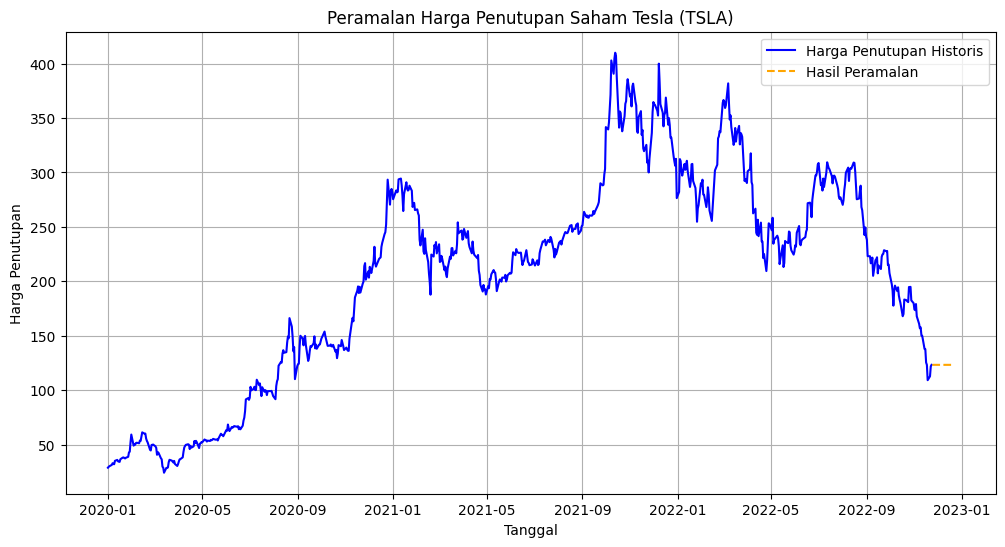

In [11]:
# Visualisasi harga penutupan historis dan hasil peramalan
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Harga Penutupan Historis', color='blue')

# Membuat indeks untuk peramalan
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_steps, freq='B')

# Plot hasil peramalan
plt.plot(forecast_index, forecast, label='Hasil Peramalan', color='orange', linestyle='--')

# Tambahkan elemen visual lainnya
plt.title('Peramalan Harga Penutupan Saham Tesla (TSLA)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.grid()
plt.show()


---
# Analisis Time Series Multivariat

VAR (Vector Autoregression)

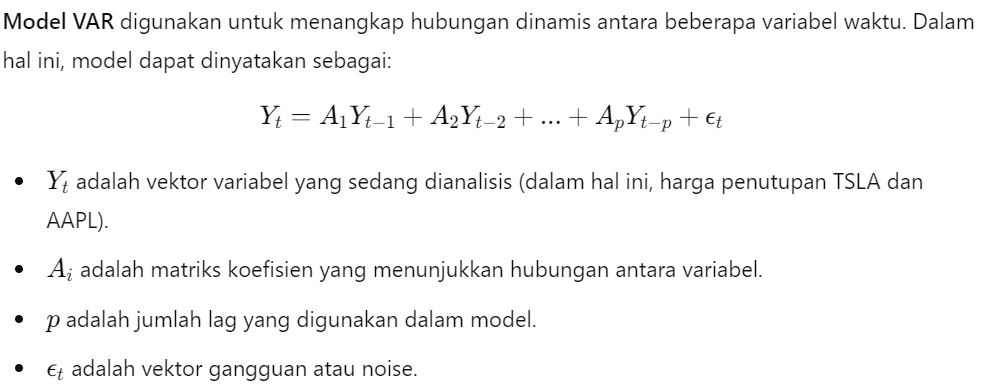

1. Import Data Tesla

[*********************100%%**********************]  2 of 2 completed

                 TSLA       AAPL
2020-01-01  28.684000  75.087502
2020-01-02  29.534000  74.357498
2020-01-03  30.102667  74.949997
2020-01-06  31.270666  74.597504
2020-01-07  32.809334  75.797501
ADF Statistic: -1.8775284728871102
p-value: 0.342705134711416
Data tidak stasioner, lakukan differencing.
ADF Statistic: -1.8953789647960477
p-value: 0.3342381045901876
Data tidak stasioner, lakukan differencing.
Differencing dilakukan untuk TSLA.
Differencing dilakukan untuk AAPL.


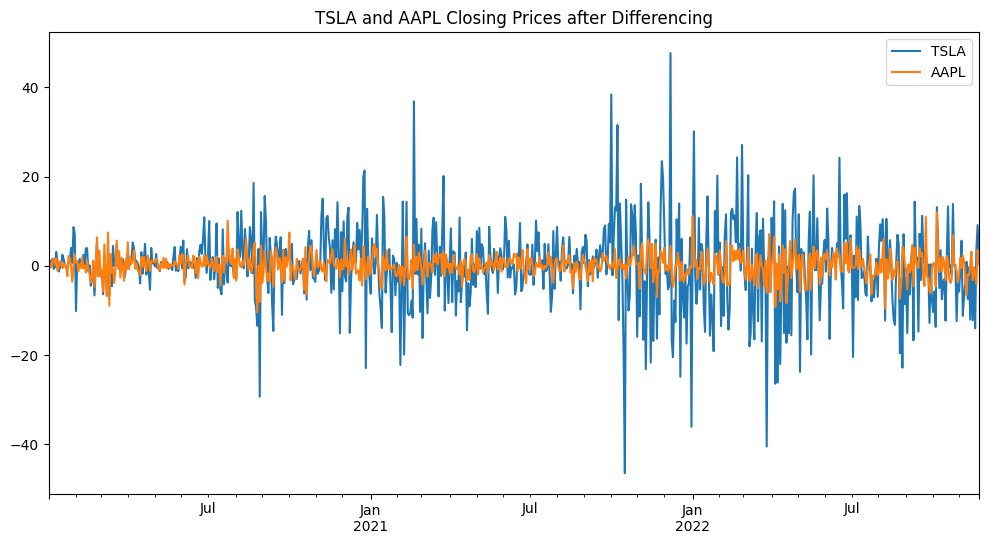

In [17]:
# Import libraries yang diperlukan
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Ambil data harga penutupan untuk TSLA dan AAPL dengan frekuensi bisnis (B)
tickers = ['TSLA', 'AAPL']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01', group_by='ticker')

# Set frekuensi pada indeks
data.index = pd.date_range(start='2020-01-01', periods=len(data), freq='B')  # B untuk hari kerja


# Ambil hanya harga penutupan
data_combined = pd.DataFrame({
    'TSLA': data['TSLA']['Close'],
    'AAPL': data['AAPL']['Close']
})

# Tampilkan beberapa baris data
print(data_combined.head())

# Fungsi untuk memeriksa stasionaritas
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] < 0.05:
        print("Data stasioner, lanjutkan analisis.")
        return True
    else:
        print("Data tidak stasioner, lakukan differencing.")
        return False

# Cek stasionaritas untuk kedua variabel
is_stationary_tsla = check_stationarity(data_combined['TSLA'])
is_stationary_aapl = check_stationarity(data_combined['AAPL'])

# Lakukan differencing jika diperlukan
if not is_stationary_tsla:
    data_combined['TSLA'] = data_combined['TSLA'].diff().dropna()
    print("Differencing dilakukan untuk TSLA.")

if not is_stationary_aapl:
    data_combined['AAPL'] = data_combined['AAPL'].diff().dropna()
    print("Differencing dilakukan untuk AAPL.")

# Hapus NaN yang mungkin ada setelah differencing
data_combined = data_combined.dropna()

# Visualisasikan data yang telah di-differencing
data_combined.plot(figsize=(12, 6), title='TSLA and AAPL Closing Prices after Differencing')
plt.show()


In [18]:
from statsmodels.tsa.api import VAR

# Langkah 1: Tentukan lag optimal
model = VAR(data_combined)
lag_order = model.select_order(maxlags=15)  # Menentukan lag optimal hingga 15 lag
print(lag_order.summary())

# Langkah 2: Buat model berdasarkan lag optimal
optimal_lag = lag_order.aic  # Menggunakan AIC untuk lag optimal
var_model = model.fit(optimal_lag)

# Langkah 3: Tampilkan ringkasan model
print(var_model.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       6.170*      6.183*      478.3*      6.175*
1        6.176       6.214       481.2       6.191
2        6.182       6.244       483.9       6.206
3        6.191       6.278       488.2       6.224
4        6.195       6.307       490.4       6.238
5        6.202       6.339       493.8       6.255
6        6.210       6.372       497.9       6.273
7        6.210       6.396       497.5       6.282
8        6.210       6.421       497.6       6.291
9        6.211       6.448       498.4       6.303
10       6.216       6.478       500.9       6.317
11       6.215       6.501       500.2       6.325
12       6.221       6.533       503.4       6.341
13       6.228       6.564       506.7       6.357
14       6.233       6.594       509.4       6.372
15       6.234       6.620       509.6       6.382
-------------------------------